# TS5 - Estimación espectral. Ventanas en acción!


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal.windows import flattop, blackmanharris, hann

plt.rcParams.update({
    "figure.figsize": (10, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11
})

## Utilidades de TS anteriores

### Generador de señales (TS-1)

In [2]:
class GeneradorSenales:

    @staticmethod
    def _resolver_parametros(ff, n, fs):
        if fs is None and n is None:
            fs = ff * 2
            n = int(fs)
        elif fs is None:
            fs = n
        elif n is None:
            n = int(fs)
        return int(n), float(fs)

    @staticmethod
    def _generar_tiempo(n, fs):
        t = np.arange(n) / fs
        return t.reshape(-1, 1)

    @staticmethod
    def generar_seno(vmax=1, dc=0, ff=1, ph=0, n=None, fs=None):
        tt = GeneradorSenales._generar_tiempo(n, fs)
        xx = dc + vmax * np.sin(2 * np.pi * tt * ff + ph)
        return tt, xx

    @staticmethod
    def generate_noisy_signal(clean, sigma=1):
        noise = np.random.normal(loc=0.0, scale=sigma, size=clean.shape)
        return clean + noise

### Implementación de la DFT (TS-2)

Para el experimento de este TP usamos `numpy.fft.fft` (es O(N log N) y vamos a hacer 200×1000 puntos), pero dejo la implementación propia como referencia.

In [3]:
def mi_funcion_DFT(xx):
    """DFT directa por matriz (TS-2). O(N^2)."""
    x = np.asarray(xx, dtype=float)
    N = x.size
    n = np.arange(N)
    k = n.reshape(-1, 1)
    n = n.reshape(1, -1)
    integer_matrix = k @ n
    W = np.exp(-1j * 2 * np.pi * integer_matrix / N)
    XX = W @ x
    return XX.reshape(-1, 1)

## Parámetros del experimento

In [4]:
# ============== Parametros ==============
N         = 1000              # muestras por realizacion
FS        = 1000              # frecuencia de muestreo
M         = 200               # realizaciones
F0        = FS / 4            # 250 Hz 
A0        = np.sqrt(2)        # amplitud para potencia 1 W
SNR_DB    = [3, 10]
VENTANAS  = ['rectangular', 'flattop', 'blackmanharris', 'hann']

DELTA_F   = FS / N            # 1 Hz
BIN_F0    = int(F0 * DELTA_F) # bin correspondiente a Omega_0 250)

In [5]:
def get_ventana(nombre, N):
    """Devuelve la ventana con N muestras."""
    if nombre == 'rectangular':
        return np.ones(N)
    if nombre == 'flattop':
        return flattop(N)
    if nombre == 'blackmanharris':
        return blackmanharris(N)
    if nombre == 'hann':
        return hann(N)
    raise ValueError(f"Ventana '{nombre}' no soportada")

def sigma_de_snr(snr_db, potencia_signal=1.0):
    """Sigma del ruido para un snr dado, para una potencia determinada (va a ser unitaria)"""
    return np.sqrt(potencia_signal / 10**(snr_db / 10))

for snr in SNR_DB:
    print(f"SNR = {snr:>2} dB  ->  sigma = {sigma_de_snr(snr):.4f}")

SNR =  3 dB  ->  sigma = 0.7079
SNR = 10 dB  ->  sigma = 0.3162


## Simulación

In [6]:
def correr_experimento(snr_db, ventana_nombre,
                       N=N, M=M, FS=FS, A0=A0, F0=F0, rng=None):
    """
    Genera M realizaciones de x(n) = seno + ruido y aplica el
    estimador de amplitud y frecuencia con la ventana

    Devuelve:
        a_hat   : (M,)  estimador de amplitud
        f_hat   : (M,)  estimador de frecuencia
        f1_real : (M,)  frecuencia verdadera
    """
    if rng is None:
        rng = np.random.default_rng()

    # Generacion de senoidal
    fr      = rng.uniform(-2, 2, size=M)
    f1_real = F0 + fr * DELTA_F                       # (M,)
    t        = np.arange(N) / FS                      # (N,)    
    senoidal = A0 * np.sin(2 * np.pi * (f1_real * t.reshape(-1, 1)).T)   # (M, N)

    # Ruido gauss
    sigma = sigma_de_snr(snr_db)
    ruido = rng.normal(0.0, sigma, size=(M, N))
    x     = senoidal + ruido                          # (M, N)

    # Ventaneo  + FFT!!!
    w  = get_ventana(ventana_nombre, N)               # (N,)
    Xw = np.fft.fft(x * w, axis=1)                    # (M, N)
    
    #Normalizo
    modulo = 2 * np.abs(Xw[:, :N // 2]) / w.sum()     # (M, N//2), ademas normalizo por w.sum()
    freqs  = np.arange(N // 2) * FS / N

    # Estimador de amplitud
    a_hat = modulo[:, BIN_F0]                         # (M,)

    # Estimador de frecuencia
    bin_max = np.argmax(modulo, axis=1)               # (M,)
    f_hat   = freqs[bin_max]                          # (M,)

    return a_hat, f_hat, f1_real



In [7]:
datos = {}        # datos[snr][ventana] = (a_hat, f_hat, f1_real)
tablas_amp  = {}  # tablas_amp[snr]  = DataFrame
tablas_frec = {}  # tablas_frec[snr] = DataFrame

for snr in SNR_DB:
    datos[snr] = {}
    filas_amp  = []
    filas_frec = []

    for v in VENTANAS:
        rng_v = np.random.default_rng(seed=42 + snr) #Repetitibiluidad
        a_hat, f_hat, f1_real = correr_experimento(snr, v, rng=rng_v)
        datos[snr][v] = (a_hat, f_hat, f1_real)

        # ---- Amplitud ----
        mu_a = a_hat.mean()
        s_a  = mu_a - A0
        v_a  = (a_hat - mu_a).var()              # 1/M (sin Bessel)
        filas_amp.append({'ventana': v, 's_a': s_a, 'v_a': v_a})

        # ---- Frecuencia ----
        err_f = f_hat - f1_real
        s_f   = err_f.mean()
        v_f   = (f_hat - f1_real).var()
        filas_frec.append({'ventana': v, 's_f': s_f, 'v_f': v_f})

    tablas_amp[snr]  = pd.DataFrame(filas_amp).set_index('ventana')
    tablas_frec[snr] = pd.DataFrame(filas_frec).set_index('ventana')

## Resultados

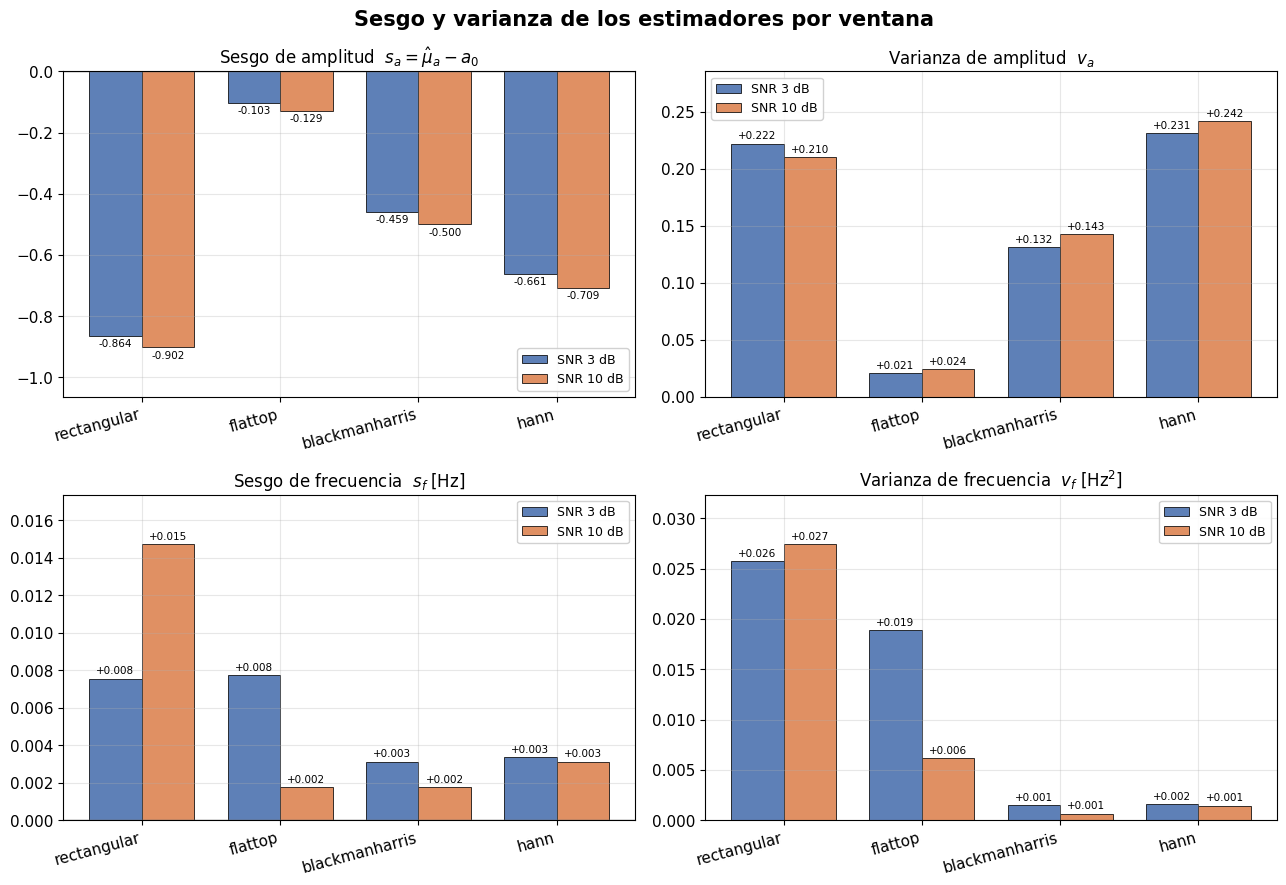

In [18]:
# ============================================================
#  Visualizacion
# ============================================================
x      = np.arange(len(VENTANAS))
ancho  = 0.38
col_snr = {SNR_DB[0]: '#4C72B0', SNR_DB[1]: '#DD8452'}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Sesgo y varianza de los estimadores por ventana",
             fontsize=15, fontweight='bold')

paneles = [
    (axes[0, 0], tablas_amp,  's_a', r"Sesgo de amplitud  $s_a=\hat{\mu}_a-a_0$", True),
    (axes[0, 1], tablas_amp,  'v_a', r"Varianza de amplitud  $v_a$",              False),
    (axes[1, 0], tablas_frec, 's_f', r"Sesgo de frecuencia  $s_f$ [Hz]",          True),
    (axes[1, 1], tablas_frec, 'v_f', r"Varianza de frecuencia  $v_f$ [Hz$^2$]",   False),
]

for ax, tabla, col, titulo, marca_cero in paneles:
    for k, snr in enumerate(SNR_DB):
        vals = tabla[snr][col].values
        off  = (k - (len(SNR_DB) - 1) / 2) * ancho
        barras = ax.bar(x + off, vals, ancho, label=f"SNR {snr} dB",
                        color=col_snr[snr], edgecolor='black',
                        linewidth=0.6, alpha=0.9)
        ax.bar_label(barras, fmt='%+.3f', fontsize=7.5, padding=2)
    ax.set_title(titulo, fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(VENTANAS, rotation=15, ha='right')
    if marca_cero:
        ax.axhline(0, color='gray', linewidth=1)
    ax.legend(fontsize=9, framealpha=0.9)
    ax.margins(y=0.18)

plt.tight_layout()
plt.show()

### Observaciones
Se observa que:

- **Los estimadores de amplitud son (relativamente) inmunes al ruido gaussiano:** esto se debe, a que la potencia del ruido, se distribuye uniformememnte por todo el espectro (AWGN), mientras que la potencia de la señal esta fuertemenre concentrada en un bin en especifico
- **Ventajas de cada ventana:** se observa claramente, como la blackman y harris tienen una MUY baja varianza en su estimador de frecuencia, mientras que una varianza muy mala en su estimador de amplitud. El caso inverso es el de la flattop.

---

## Histogramas

### Amplitud

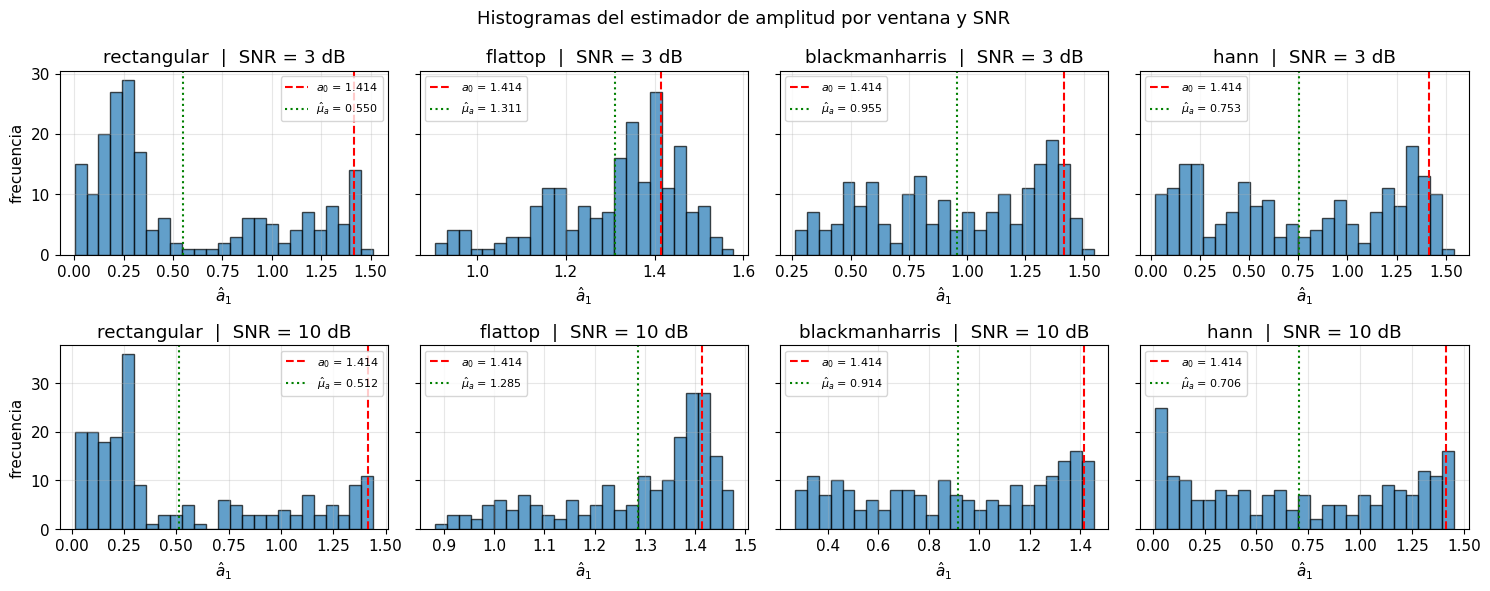

In [9]:
fig, axes = plt.subplots(len(SNR_DB), len(VENTANAS),
                         figsize=(15, 6), sharey='row')

for i, snr in enumerate(SNR_DB):
    for j, v in enumerate(VENTANAS):
        a_hat, _, _ = datos[snr][v]
        ax = axes[i, j]
        ax.hist(a_hat, bins=25, edgecolor='black', alpha=0.7)
        ax.axvline(A0, color='red', linestyle='--', linewidth=1.5, label=f'$a_0$ = {A0:.3f}')
        ax.axvline(a_hat.mean(), color='green', linestyle=':', linewidth=1.5,
                   label=f'$\\hat{{\\mu}}_a$ = {a_hat.mean():.3f}')
        ax.set_title(f"{v}  |  SNR = {snr} dB")
        ax.set_xlabel(r"$\hat{a}_1$")
        if j == 0:
            ax.set_ylabel("frecuencia")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

fig.suptitle("Histogramas del estimador de amplitud por ventana y SNR", fontsize=13)
plt.tight_layout()
plt.show()

### Frecuencia

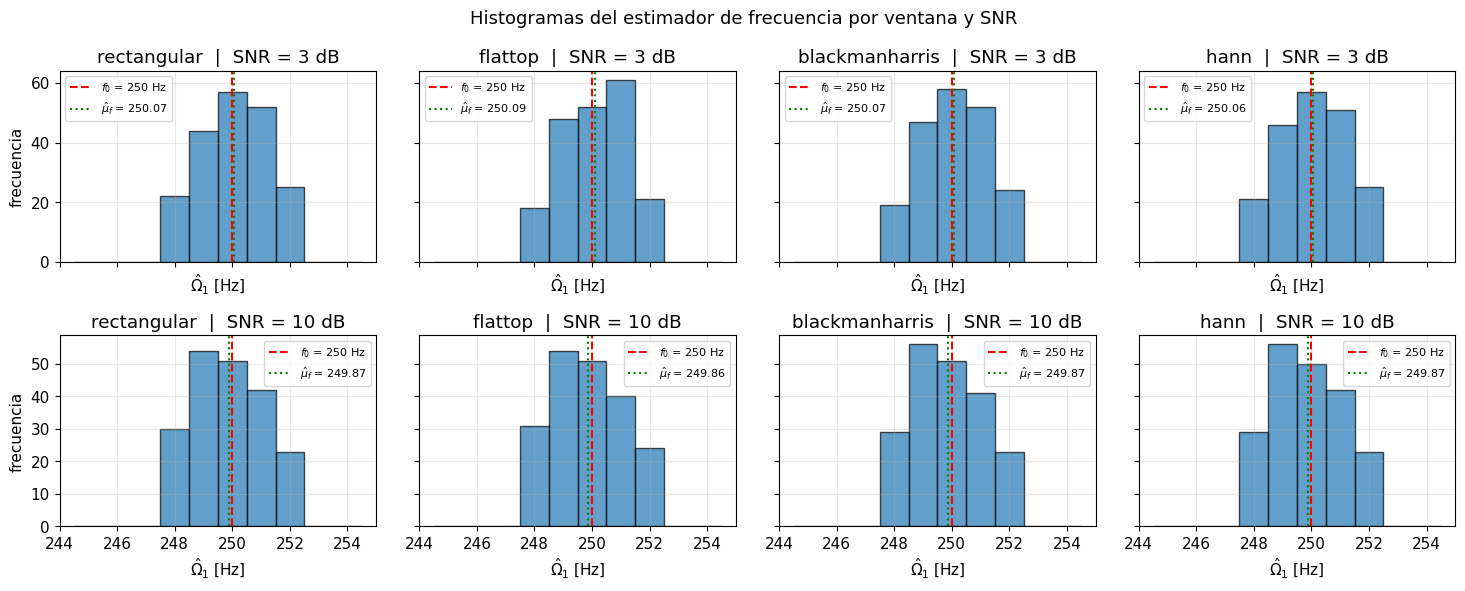

In [10]:
fig, axes = plt.subplots(len(SNR_DB), len(VENTANAS),
                         figsize=(15, 6), sharey='row', sharex=True)

for i, snr in enumerate(SNR_DB):
    for j, v in enumerate(VENTANAS):
        _, f_hat, _ = datos[snr][v]
        ax = axes[i, j]
        # bins centrados en valores enteros (porque la resolución es 1 Hz)
        bordes = np.arange(F0 - 5.5, F0 + 5.5, 1.0)
        ax.hist(f_hat, bins=bordes, edgecolor='black', alpha=0.7)
        ax.axvline(F0, color='red', linestyle='--', linewidth=1.5, label=f'$f_0$ = {F0:.0f} Hz')
        ax.axvline(f_hat.mean(), color='green', linestyle=':', linewidth=1.5,
                   label=f'$\\hat{{\\mu}}_f$ = {f_hat.mean():.2f}')
        ax.set_title(f"{v}  |  SNR = {snr} dB")
        ax.set_xlabel(r"$\hat{\Omega}_1$ [Hz]")
        if j == 0:
            ax.set_ylabel("frecuencia")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

fig.suptitle("Histogramas del estimador de frecuencia por ventana y SNR", fontsize=13)
plt.tight_layout()
plt.show()

### Espectro por ventana

Para visualizar como cada ventana modifica el espectro de la señal (se usa unicamente un SNR de 10)

In [11]:
def make_fft(snr_db, ventana_nombre,
                   N=N, M=M, FS=FS, A0=A0, F0=F0, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    
    # Generacion de senoidal
    fr      = rng.uniform(-2, 2, size=M)
    f1_real = F0 + fr * DELTA_F                       # (M,)
    t        = np.arange(N) / FS                      # (N,)    
    senoidal = A0 * np.sin(2 * np.pi * (f1_real * t.reshape(-1, 1)).T)   # (M, N)
    
    # Ruido gauss
    sigma = sigma_de_snr(snr_db)
    ruido = rng.normal(0.0, sigma, size=(M, N))
    x     = senoidal + ruido                          # (M, N)
    
    # Ventaneo  + FFT!!!
    w  = get_ventana(ventana_nombre, N)               # (N,)
    Xw = np.fft.fft(x * w, axis=1)                    # (M, N)
    
    #Normalizo
    modulo = 2 * np.abs(Xw[:, :N // 2]) / w.sum()     # (M, N//2)
    freqs  = np.arange(N // 2) * FS / N
    
    # Estimador de amplitud
    a_hat = modulo[:, BIN_F0]                         # (M,)
    
    # Estimador de frecuencia
    bin_max = np.argmax(modulo, axis=1)               # (M,)
    f_hat   = freqs[bin_max]                          # (M,)
    
    return a_hat, f_hat, f1_real



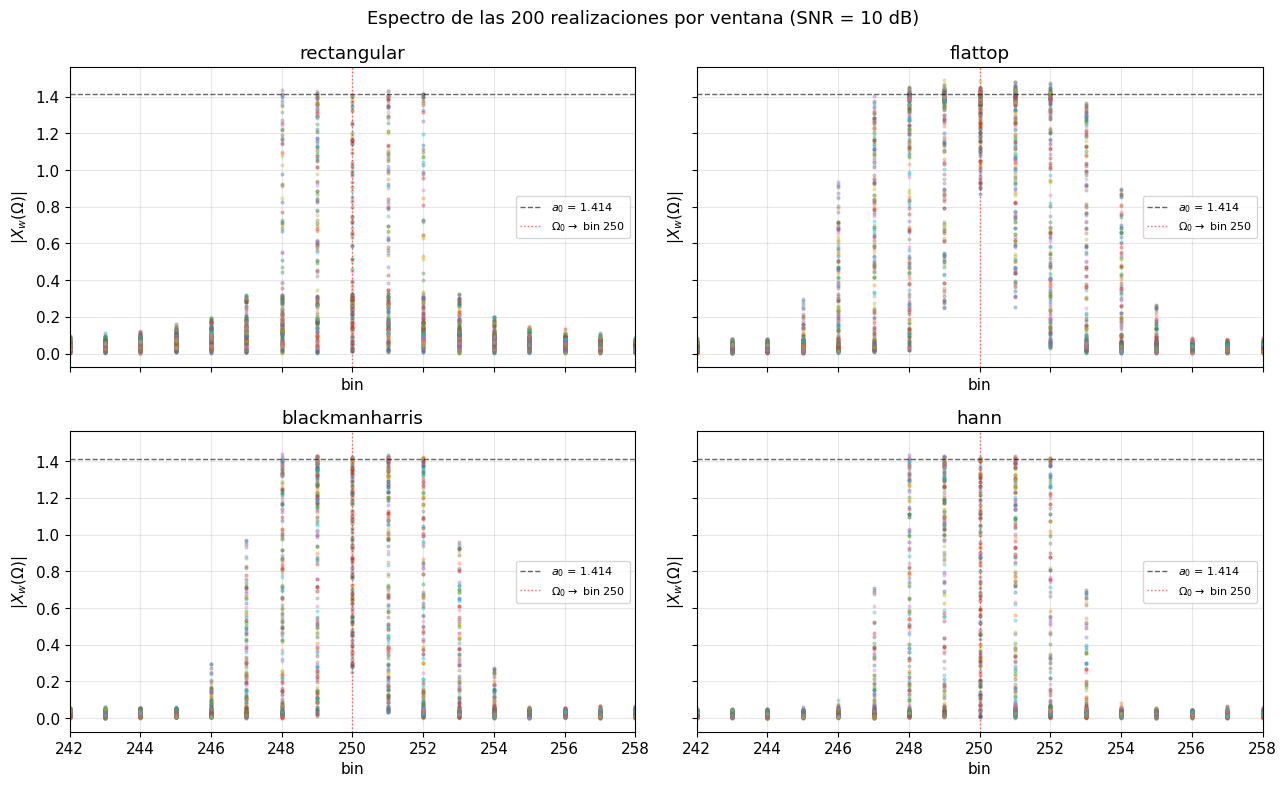

In [12]:
snr_db = 10  # SNR para este plot

rng = np.random.default_rng()

# Generacion de senoidal
fr      = rng.uniform(-2, 2, size=M)
f1_real = F0 + fr * DELTA_F                       # (M,)
t        = np.arange(N) / FS                      # (N,)    
senoidal = A0 * np.sin(2 * np.pi * (f1_real * t.reshape(-1, 1)).T)   # (M, N)

# Ruido gauss
sigma = sigma_de_snr(snr_db)
ruido = rng.normal(0.0, sigma, size=(M, N))
x     = senoidal + ruido                          # (M, N)

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True, sharey=True)

for ax, v in zip(axes.flat, VENTANAS):
    w  = get_ventana(v, N)
    Xw = np.fft.fft(x * w, axis=1)
    
    modulo = 2 * np.abs(Xw[:, :N//2]) / w.sum()
    bins   = np.arange(N//2)
    
    ax.plot(bins, modulo.T, 'o', markersize=2, alpha=0.3)
    ax.axhline(A0, color='k', linestyle='--', linewidth=1, alpha=0.6, label=f'$a_0$ = {A0:.3f}')
    ax.axvline(BIN_F0, color='red', linestyle=':', linewidth=1, alpha=0.6, label=f'$\\Omega_0 \\to$ bin {BIN_F0}')
    ax.set_title(v)
    ax.set_xlim(BIN_F0 - 8, BIN_F0 + 8)
    ax.set_xlabel("bin")
    ax.set_ylabel(r"$|X_w(\Omega)|$")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle(f"Espectro de las {M} realizaciones por ventana (SNR = {snr_db} dB)", fontsize=13)
plt.tight_layout()
plt.show()

### Plotteo de ventanas

Se plotean a continuacion, diferentes ventanas para analizar la composicion de sus lobulos

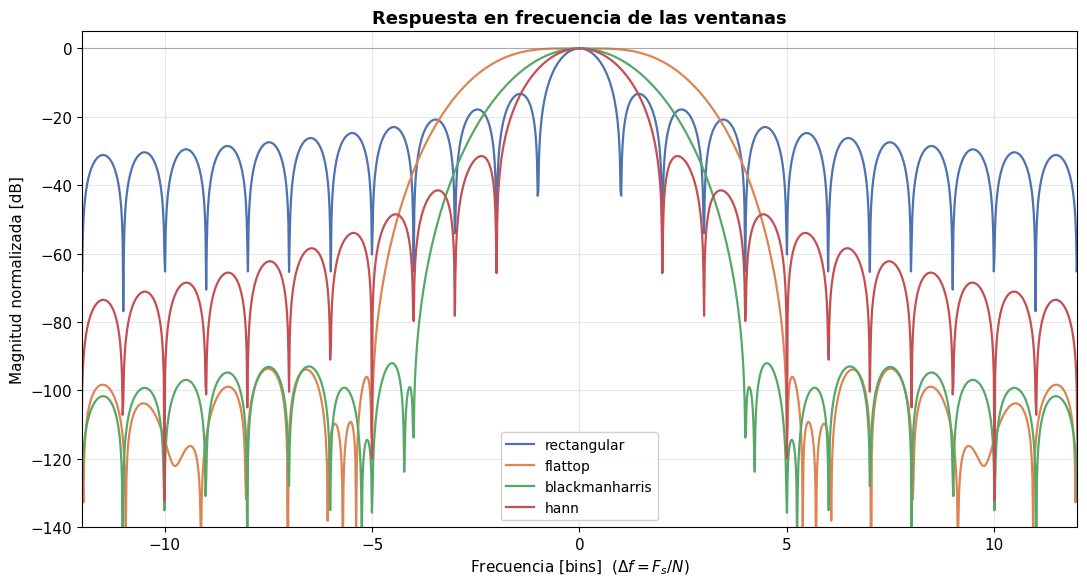

In [20]:
# ============================================================
#  Respuesta en frecuencia de las ventanas (en dB)
# ============================================================
NFFT = 1 << 16                                      # zero-padding -> respuesta suave
bins = np.fft.fftshift(np.fft.fftfreq(NFFT)) * N    # eje en "bins" de la ventana de largo N

colores = {'rectangular':'#4C72B0', 'flattop':'#DD8452',
           'blackmanharris':'#55A868', 'hann':'#C44E52'}

fig, ax = plt.subplots(figsize=(11, 6))

for v in VENTANAS:
    w   = get_ventana(v, N)
    W   = np.fft.fftshift(np.fft.fft(w, NFFT))
    Wdb = 20 * np.log10(np.abs(W) / np.abs(W).max() + 1e-300)   # pico normalizado a 0 dB
    ax.plot(bins, Wdb, label=v, color=colores[v], linewidth=1.6)

ax.set_xlim(-12, 12)
ax.set_ylim(-140, 5)
ax.set_xlabel(r"Frecuencia [bins]  ($\Delta f = F_s/N$)")
ax.set_ylabel("Magnitud normalizada [dB]")
ax.set_title("Respuesta en frecuencia de las ventanas", fontsize=13, fontweight='bold')
ax.axhline(0, color='gray', linewidth=0.8, alpha=0.6)
ax.legend(fontsize=10, framealpha=0.9)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusiones

### Estimador de amplitud
Las ventanas de lobulo mas "ancho" estiman mejor el valor real de la señal (ya que toma todas las componentes de espectro desparramadas)
- **Rectangular**: peor tiene mucho sesgo por que tiene un lobulo bastante chico. Pero sus lobulos secundarios estan muy poco atenuados
- **Hann** y **Blackman-Harris**: Ensanchan bastante el lobulo pricipal, pero atenuan significativamente los lobulos mas lejanos. POR ENDE termina generando mejor estimador que la rectangular. (aunque la hann termina dando mayor varianza)
- **Flat-top**: Es la mejor estimadno amplitudes (de hecho existe para eso). es la de mayor lobulo principal, asi que toma para si mismo todo lo que sea cercano. Es la de mejor varianza entre las 4
- 
### Estimador de frecuencia
- Las ventanas de lóbulo principal angosto localizan mejor el pico.
- **Rectangular**, **Hann** y **Blackman-Harris**: Sus lobulos localizan bastante bien la frecuencia central, dejandola con poca varianza
- **Flat-top**: el tope plano que la hacia ganadora en amplitud juega en contra. al tener un lobulo princiapl muy grande, "junta" varios bines de distintas frecuencias. desparramando aun mas el espectro

---

# Bonus 1: efecto del zero-padding sobre $\hat{\Omega}_1$

El zero padding **NO mejora la resolucion espectral real**, si dos senoidales estan separadas por menos de DELTA_F, sus lobulos se seguiran solapando. lo que SI hace es **Interpolar el espectro** aumentando la resolucion ficticia de la grilal con la que se muestrea.

Como consecuencia, el `argmax` cae mas cerca del veerdadero valor, **Mejorando la localizaciopn del pico**

En cambio, el estimador de amplitud **NO se ve afectado**: ya que la formula del lobulo no cambia. Solo estamos "refinando" lo que ya tenemos

In [13]:
def correr_experimento_zp(snr_db, ventana_nombre, K,
                          N=N, M=M, FS=FS, A0=A0, F0=F0, rng=None):
    """Igual que correr_experimento pero con zero-padding factor K"""
    if rng is None:
        rng = np.random.default_rng()

    # Generacion de senoidal
    fr      = rng.uniform(-2, 2, size=M)
    f1_real = F0 + fr * DELTA_F                       # (M,)
    t        = np.arange(N) / FS                      # (N,)    
    senoidal = A0 * np.sin(2 * np.pi * (f1_real * t.reshape(-1, 1)).T)   # (M, N)

    # Ruido gauss
    sigma = sigma_de_snr(snr_db)
    ruido = rng.normal(0.0, sigma, size=(M, N))
    x     = senoidal + ruido                          # (M, N)
    
    # Ventaneo  + FFT!!!
    w  = get_ventana(ventana_nombre, N)               # (N,)
    Np = N * K
    Xw = np.fft.fft(x * w, n = Np, axis=1)                    # (M, N)
    
    #Normalizo
    modulo = 2 * np.abs(Xw[:, :Np // 2]) / w.sum()     # (M, N//2)
    freqs  = np.arange(Np // 2) * FS / Np

    # Estimador de frecuencia
    bin_max = np.argmax(modulo, axis=1)               # (M,)
    f_hat   = freqs[bin_max]                          # (M,)

    return f_hat, f1_real


In [14]:
KS        = [1, 2, 4, 8, 16, 32]
SNR_BONUS = 10  # SNR fijo para este experimento

var_zp = {v: [] for v in VENTANAS}
ses_zp = {v: [] for v in VENTANAS}

for v in VENTANAS:
    for K in KS:
        rng = np.random.default_rng(seed=42 + SNR_BONUS)
        f_hat, f1_real = correr_experimento_zp(SNR_BONUS, v, K, rng=rng)
        err = f_hat - f1_real
        # ses_zp[v].append(err.mean())
        var = (f_hat - f1_real).var()
        var_zp[v].append(var)

# Tabla de varianzas
df_zp = pd.DataFrame(var_zp, index=[f"K={k}" for k in KS]).T
df_zp.index.name = 'ventana'
print(f"Varianza del estimador de frecuencia [Hz²]  (SNR = {SNR_BONUS} dB)\n")
print(df_zp.to_string(float_format='%.3f'))

Varianza del estimador de frecuencia [Hz²]  (SNR = 10 dB)

                 K=1   K=2   K=4   K=8  K=16  K=32
ventana                                           
rectangular    0.081 0.021 0.005 0.001 0.000 0.000
flattop        0.129 0.130 0.138 0.150 0.154 0.154
blackmanharris 0.081 0.021 0.005 0.002 0.001 0.000
hann           0.081 0.021 0.005 0.001 0.000 0.000


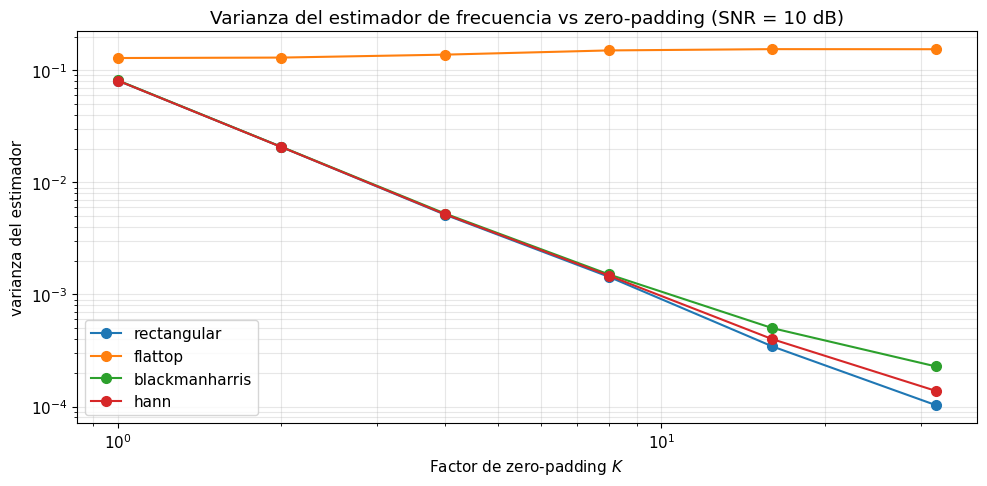

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
for v in VENTANAS:
    ax.loglog(KS, var_zp[v], 'o-', label=v, linewidth=1.5, markersize=7)

ax.set_xlabel("Factor de zero-padding $K$")
ax.set_ylabel("varianza del estimador")
ax.set_title(f"Varianza del estimador de frecuencia vs zero-padding (SNR = {SNR_BONUS} dB)")
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

---
# 🤯 Proponga estimadores alternativos para frecuencia y amplitud de la senoidal y repita el experimento.

En este caso, yo voy a proponer una *interpolacion cuadratica sobre los maximos bins* (https://ccrma.stanford.edu/~jos/sasp/Quadratic_Interpolation_Spectral_Peaks.html)

que permite extraer frecuencia/amplitud maximos

In [47]:
def correr_experimento(snr_db, ventana_nombre,
                       N=N, M=M, FS=FS, A0=A0, F0=F0, rng=None):
    """
    Estimador de frecuencia Y amplitud por Quadratic Interpolation.
    """
    if rng is None:
        rng = np.random.default_rng()
    
    # Generacion de senoidal
    fr       = rng.uniform(-2, 2, size=M)
    f1_real  = F0 + fr * DELTA_F                       # (M,)
    t        = np.arange(N) / FS                       # (N,)
    senoidal = A0 * np.sin(2 * np.pi * (f1_real * t.reshape(-1, 1)).T)   # (M, N)

    # Ruido gauss
    sigma = sigma_de_snr(snr_db)
    ruido = rng.normal(0.0, sigma, size=(M, N))
    x     = senoidal + ruido                           # (M, N)

    # Ventaneo + FFT
    w      = get_ventana(ventana_nombre, N)
    Xw     = np.fft.fft(x * w, axis=1)
    modulo = 2 * np.abs(Xw[:, :N // 2]) / w.sum()      # (M, N//2)

    # ===== Interpolación parabólica (3 puntos alrededor del pico) =====
    rows  = np.arange(M)
    kc     = np.argmax(modulo, axis=1)                  # bin del pico por realización

    y_betha = modulo[rows, kc]                              # pico
    y_alpha = modulo[rows, kc - 1]                          # vecino izquierdo
    y_gamma = modulo[rows, kc + 1]                          # vecino derecho

    num = y_alpha - y_gamma
    den = y_alpha - 2 * y_betha + y_gamma
    p   = 0.5 * num/den
    
    f_hat = (kc + p) * DELTA_F
    a_hat = y_betha - 0.25 * (y_alpha - y_gamma) * p
    

    return a_hat, f_hat, f1_real

In [48]:
datos = {}        # datos[snr][ventana] = (a_hat, f_hat, f1_real)
tablas_amp  = {}  # tablas_amp[snr]  = DataFrame
tablas_frec = {}  # tablas_frec[snr] = DataFrame

for snr in SNR_DB:
    datos[snr] = {}
    filas_amp  = []
    filas_frec = []

    for v in VENTANAS:
        rng_v = np.random.default_rng(seed=42 + snr) #Repetitibiluidad
        a_hat, f_hat, f1_real = correr_experimento(snr, v, rng=rng_v)
        datos[snr][v] = (a_hat, f_hat, f1_real)

        # ---- Amplitud ----
        mu_a = a_hat.mean()
        s_a  = mu_a - A0
        v_a  = (a_hat - mu_a).var()              # 1/M (sin Bessel)
        filas_amp.append({'ventana': v, 's_a': s_a, 'v_a': v_a})

        # ---- Frecuencia ----
        err_f = f_hat - f1_real
        s_f   = err_f.mean()
        v_f   = (f_hat - f1_real).var()
        filas_frec.append({'ventana': v, 's_f': s_f, 'v_f': v_f})

    tablas_amp[snr]  = pd.DataFrame(filas_amp).set_index('ventana')
    tablas_frec[snr] = pd.DataFrame(filas_frec).set_index('ventana')

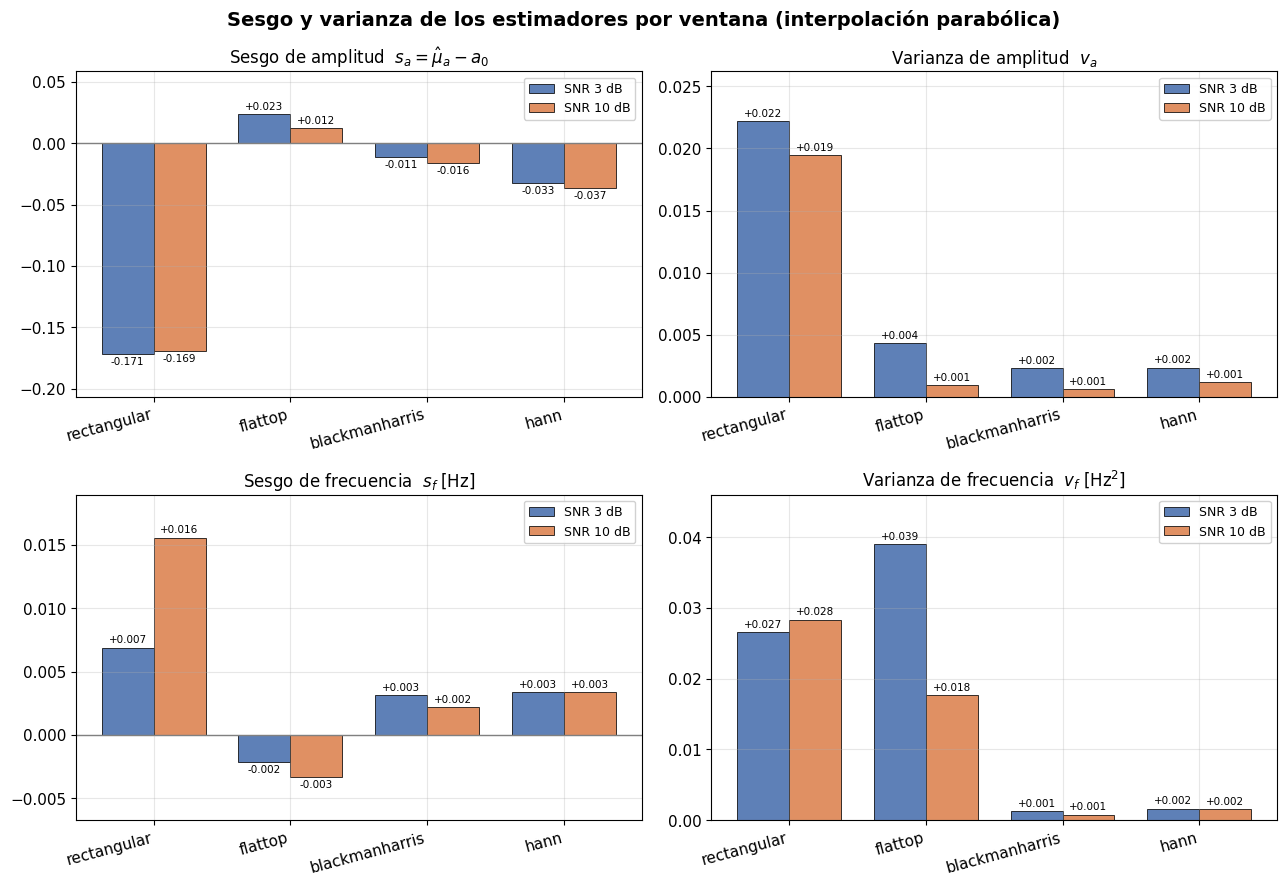

In [49]:
# ============================================================
#  Visualización de sesgo y varianza por ventana
# ============================================================
x      = np.arange(len(VENTANAS))
ancho  = 0.38
col_snr = {SNR_DB[0]: '#4C72B0', SNR_DB[1]: '#DD8452'}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle("Sesgo y varianza de los estimadores por ventana (interpolación parabólica)",
             fontsize=14, fontweight='bold')

paneles = [
    (axes[0, 0], tablas_amp,  's_a', r"Sesgo de amplitud  $s_a=\hat{\mu}_a-a_0$", True),
    (axes[0, 1], tablas_amp,  'v_a', r"Varianza de amplitud  $v_a$",              False),
    (axes[1, 0], tablas_frec, 's_f', r"Sesgo de frecuencia  $s_f$ [Hz]",          True),
    (axes[1, 1], tablas_frec, 'v_f', r"Varianza de frecuencia  $v_f$ [Hz$^2$]",   False),
]

for ax, tabla, col, titulo, marca_cero in paneles:
    for k, snr in enumerate(SNR_DB):
        vals = tabla[snr][col].values
        off  = (k - (len(SNR_DB) - 1) / 2) * ancho
        barras = ax.bar(x + off, vals, ancho, label=f"SNR {snr} dB",
                        color=col_snr[snr], edgecolor='black',
                        linewidth=0.6, alpha=0.9)
        ax.bar_label(barras, fmt='%+.3f', fontsize=7.5, padding=2)
    ax.set_title(titulo, fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(VENTANAS, rotation=15, ha='right')
    if marca_cero:
        ax.axhline(0, color='gray', linewidth=1)
    ax.legend(fontsize=9, framealpha=0.9)
    ax.margins(y=0.18)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()